In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import random
from PIL import Image
from pathlib import Path

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)
        pt = probs[range(len(targets)), targets]
        log_pt = log_probs[range(len(targets)), targets]
        focal_loss = -(1 - pt) ** self.gamma * log_pt
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

In [ ]:
class ConvNeXtTiny(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.convnext_tiny(weights=weights)
        in_features = 768
        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.35),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [ ]:
class RAFDB(Dataset):
    def __init__(self, root_dir, train=False):
        self.root_dir = Path(root_dir)
        self.train = train
        self.images = []
        self.labels = []
        self._load_data()

        if self.train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(224, scale=(0.82, 1.0), ratio=(0.9, 1.1)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=12),
                transforms.RandomApply([transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08)], p=0.6),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            class_idx = int(class_folder.name)
            label = class_idx - 1
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in class_folder.glob(ext):
                    self.images.append(str(img_path))
                    self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
def create_dataloaders(train_dir, val_dir, test_dir, batch_size=32):
    emotion_labels = {0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'}
    train_dataset = RAFDB(train_dir, train=True)
    val_dataset = RAFDB(val_dir, train=False)
    test_dataset = RAFDB(test_dir, train=False)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader, emotion_labels

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50, device='cuda', patience=12, min_delta=0.001, checkpoint_dir="ConvNeXt"):
    save_path = Path(checkpoint_dir)
    save_path.mkdir(parents=True, exist_ok=True)
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_val_acc = -float('inf')
    epochs_no_improve = 0
    best_epoch = 0
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            train_pbar.set_postfix(Loss=f'{loss.item():.4f}', Acc=f'{100.*correct/total:.2f}%')
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)


        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]  ')
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_pbar.set_postfix(Loss=f'{loss.item():.4f}', Acc=f'{100.*correct/total:.2f}%')
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        scheduler.step(val_loss)

        improved = val_acc > best_val_acc + min_delta
        if improved:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_no_improve = 0
            best_path = Path(checkpoint_dir) / "best_model.pth"
            torch.save({'epoch': best_epoch, 'model_state_dict': model.state_dict(), 'val_acc': best_val_acc,}, best_path)
            print(f"НОВАЯ ЛУЧШАЯ МОДЕЛЬ: val acc {val_acc:.2f}% (эпоха {best_epoch})")
        else:
            epochs_no_improve += 1
            print(f"Нет улучшения ({epochs_no_improve}/{patience})")
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping на эпохе {epoch+1}")
                print(f"Лучшая val acc: {best_val_acc:.2f}% (эпоха {best_epoch})")
                break
        print(f"Epoch {epoch+1:2d}/{num_epochs}: "f"train {train_loss:.4f} / {train_acc:5.2f}% | "f"val {val_loss:.4f} / {val_acc:5.2f}%\n")
    best_path = Path(checkpoint_dir) / "best_model.pth"
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Загружена лучшая модель (эп. {ckpt['epoch']}, val acc {ckpt['val_acc']:.2f}%)")
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'stopped_epoch': epoch + 1 if epochs_no_improve >= patience else num_epochs
    }

In [ ]:
def test_model(model, test_loader, criterion, device, emotion_labels):
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0.0
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Тестирование'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    test_loss /= len(test_loader)
    test_acc = accuracy_score(all_labels, all_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
    _, _, f1_macro, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    print("\nPer-class metrics:")
    for i, lbl in emotion_labels.items():
        print(f" {lbl}: F1={f1[i]:.3f}, Prec={precision[i]:.3f}, Rec={recall[i]:.3f}")
    return all_preds, all_labels, test_loss, test_acc

In [ ]:
def plot_confusion_matrix(y_true, y_pred, emotion_labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_losses'], label='Train Loss')
    axes[0].plot(history['val_losses'], label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(history['train_accs'], label='Train Acc')
    axes[1].plot(history['val_accs'], label='Val Acc')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
TRAIN_DIR = r"train_occluded_50"
VAL_DIR = r"val_original"
TEST_DIR = r"occluded_test_dataset"
CHECKPOINT_DIR = "checkpoints_convnext_tiny"
BATCH_SIZE = 32
LEARNING_RATE = 5e-5
NUM_EPOCHS = 50
RANDOM_SEED = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

Устройство: cuda
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 191MB/s] 


  Всего параметров: 28,217,447


Epoch 1/50 [Train]:   0%|          | 0/326 [00:00<?, ?it/s]

Epoch 1/50 [Val]  :   0%|          | 0/58 [00:00<?, ?it/s]

...

Epoch 38/50 [Val]  :   0%|          | 0/58 [00:00<?, ?it/s]

Нет улучшения (11/12)
Epoch 38/50: train 0.0137 / 99.06% | val 0.3733 / 85.33%



Epoch 39/50 [Train]:   0%|          | 0/326 [00:00<?, ?it/s]

Epoch 39/50 [Val]  :   0%|          | 0/58 [00:00<?, ?it/s]

Нет улучшения (12/12)

Early stopping на эпохе 39
Лучшая val acc: 85.44% (эпоха 27)
Загружена лучшая модель (эп. 27, val acc 85.44%)


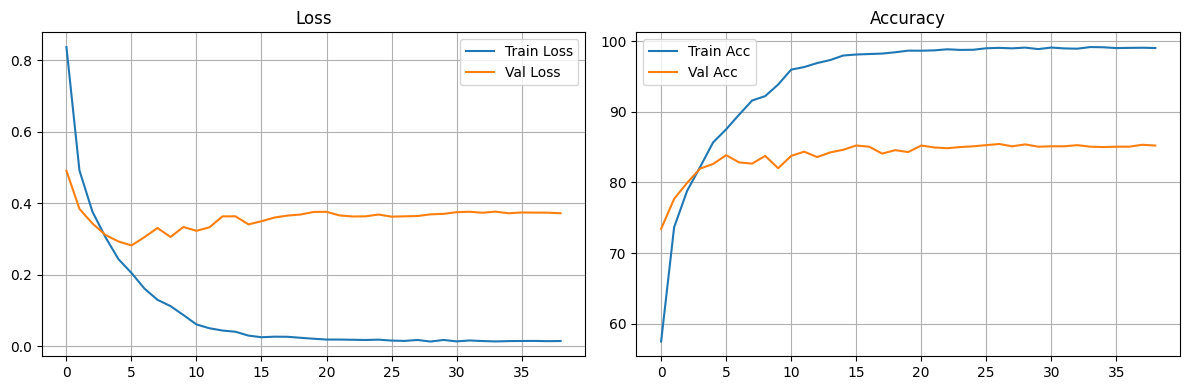

Тестирование:   0%|          | 0/96 [00:00<?, ?it/s]


Test Loss: 0.3869
Test Accuracy: 84.49%
Macro F1-Score: 0.7616

Per-class metrics:
 Surprise: F1=0.847, Prec=0.815, Rec=0.881
 Fear: F1=0.610, Prec=0.642, Rec=0.581
 Disgust: F1=0.536, Prec=0.570, Rec=0.506
 Happiness: F1=0.937, Prec=0.953, Rec=0.922
 Sadness: F1=0.820, Prec=0.807, Rec=0.833
 Anger: F1=0.765, Prec=0.765, Rec=0.765
 Neutral: F1=0.815, Prec=0.803, Rec=0.828


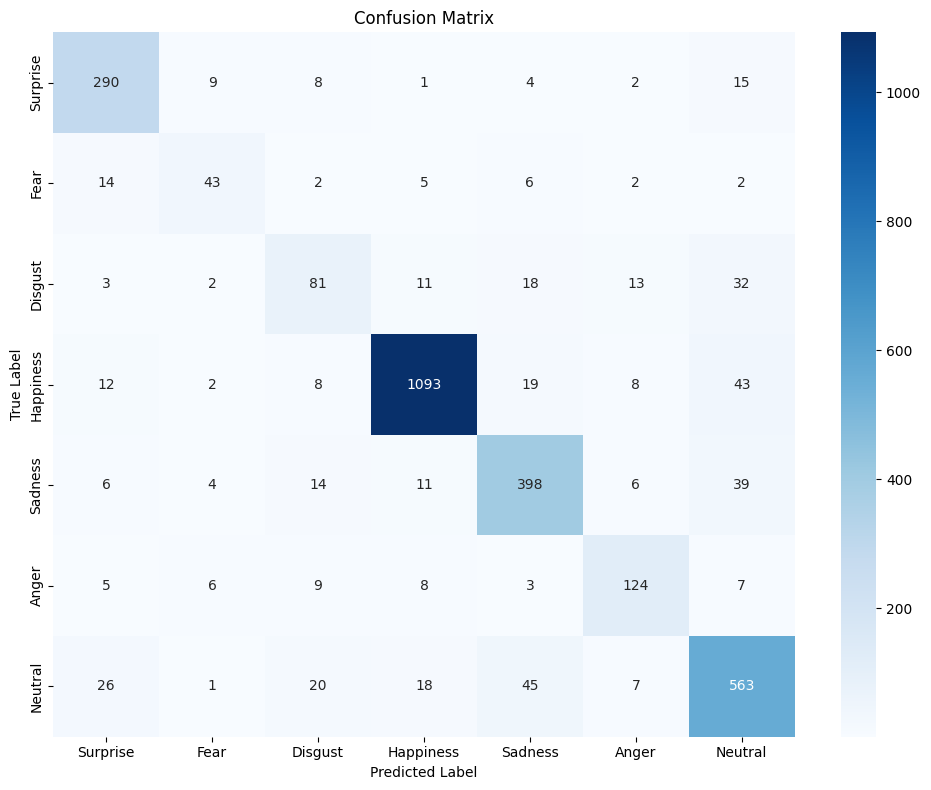

Точность на тесте: 84.49%


In [ ]:
print(f"Устройство: {device}")
train_loader, val_loader, test_loader, emotion_labels = create_dataloaders(train_dir=TRAIN_DIR, val_dir=VAL_DIR, test_dir=TEST_DIR, batch_size=BATCH_SIZE)
model = ConvNeXtTiny(num_classes=7, pretrained=True).to(device)
print(f"Всего параметров: {sum(p.numel() for p in model.parameters()):,}")
criterion = FocalLoss(gamma=1.5, alpha=None)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=3e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7)
history = train_model(model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, num_epochs=NUM_EPOCHS, device=device, patience=12, min_delta=0.001, checkpoint_dir=CHECKPOINT_DIR)
plot_training_history(history)
all_preds, all_labels, test_loss, test_acc = test_model(model=model, test_loader=test_loader, criterion=criterion, device=device, emotion_labels=emotion_labels)
plot_confusion_matrix(all_labels, all_preds, emotion_labels)
print(f"Точность на тесте: {test_acc:.2f}%")